In [2]:
original_structure = [
    'train/images', 'train/labels',
    'valid/images', 'valid/labels',
    'test/images', 'test/labels'
]
print("Original roboflow structure:")
for i in original_structure:
    print(f' - {i} ')

print("\nRestructured YOLO flat structure dataset:")
restructured_structure = [
    'images/train', 'labels/train',
    'images/valid', 'labels/valid',
    'images/test', 'labels/test'
]
for i in restructured_structure:
    print(f' - {i} ')

Original roboflow structure:
 - train/images 
 - train/labels 
 - valid/images 
 - valid/labels 
 - test/images 
 - test/labels 

Restructured YOLO flat structure dataset:
 - images/train 
 - labels/train 
 - images/valid 
 - labels/valid 
 - images/test 
 - labels/test 


In [3]:
from pathlib import Path
import shutil

# Root folder downloaded by Roboflow
dataset_dir = Path(r"American-sign-language-2")

# Convert Roboflow YOLO structure: split/type -> type/split
for split in ("train", "valid", "test"):
    for data_type in ("images", "labels"):
        src = dataset_dir / split / data_type          # e.g., train/images
        dst = dataset_dir / data_type / split          # e.g., images/train
        dst.mkdir(parents=True, exist_ok=True)

        if src.exists():
            for file_path in src.iterdir():
                target = dst / file_path.name
                if not target.exists():
                    shutil.move(str(file_path), str(target))

# Remove old empty folders
for split in ("train", "valid", "test"):
    for data_type in ("images", "labels"):
        old_dir = dataset_dir / split / data_type
        if old_dir.exists() and not any(old_dir.iterdir()):
            old_dir.rmdir()
    split_dir = dataset_dir / split
    if split_dir.exists() and not any(split_dir.iterdir()):
        split_dir.rmdir()

print("YOLO flat structure created at:", dataset_dir)
for path_str in ["images/train", "labels/train", "images/valid", "labels/valid", "images/test", "labels/test"]:
    p = dataset_dir / path_str
    print(f"- {path_str}: {'OK' if p.exists() else 'MISSING'}")

YOLO flat structure created at: American-sign-language-2
- images/train: OK
- labels/train: OK
- images/valid: OK
- labels/valid: OK
- images/test: OK
- labels/test: OK


In [4]:
# Count total number of images in YOLO flat structure: images/train, images/valid, images/test
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
image_root = dataset_dir / "images"

split_counts = {}
total_images = 0

for split in ("train", "valid", "test"):
    split_path = image_root / split
    count = 0
    if split_path.exists():
        count = sum(
            1 for f in split_path.rglob("*")
            if f.is_file() and f.suffix.lower() in image_exts
        )
    split_counts[split] = count
    total_images += count

print("Image counts by split:")
for split, count in split_counts.items():
    print(f"- {split}: {count}")

print(f"\nTotal number of images: {total_images}")

Image counts by split:
- train: 17906
- valid: 1546
- test: 822

Total number of images: 20274


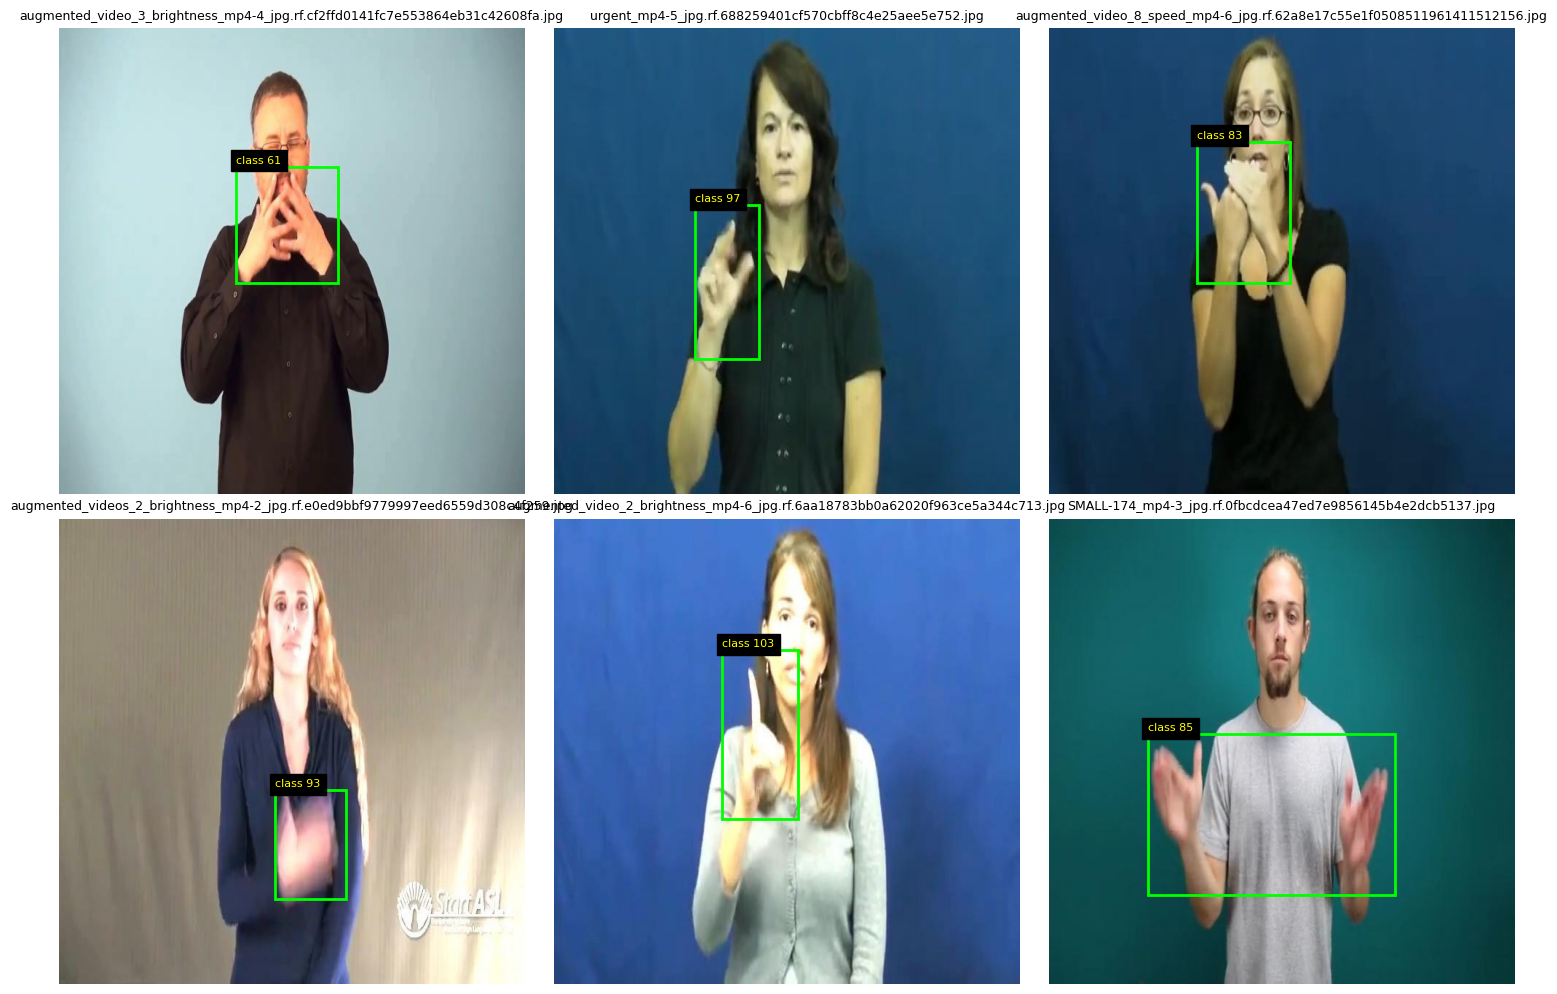

In [5]:
import random
from matplotlib.patches import Rectangle
from PIL import Image

import matplotlib.pyplot as plt

# Paths in your restructured YOLO dataset
train_images_dir = dataset_dir / "images" / "train"
train_labels_dir = dataset_dir / "labels" / "train"

# Pick a few random training images
train_images = [p for p in train_images_dir.rglob("*") if p.is_file() and p.suffix.lower() in image_exts]
n_samples = min(6, len(train_images))
sample_images = random.sample(train_images, n_samples)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, img_path in zip(axes, sample_images):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

    label_path = train_labels_dir / f"{img_path.stem}.txt"
    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls_id, x_c, y_c, bw, bh = parts
                x_c, y_c, bw, bh = map(float, (x_c, y_c, bw, bh))

                # YOLO normalized -> pixel coords
                x1 = (x_c - bw / 2) * w
                y1 = (y_c - bh / 2) * h
                box_w = bw * w
                box_h = bh * h

                rect = Rectangle((x1, y1), box_w, box_h, fill=False, edgecolor="lime", linewidth=2)
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, f"class {cls_id}", color="yellow", fontsize=8, backgroundcolor="black")

# Hide unused axes if fewer than 6 images
for i in range(len(sample_images), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
from ultralytics.utils import YAML

# Dataset root that contains images/ and labels/ folders.
dataset_root = Path(r"American-sign-language-2")

# Update class names if needed.
class_names = [
    "cup", "tomato", "spoon", "pizza", "fork", "chicken", "cake", "water",
    "bag", "sandwich", "milk", "bread", "cheese", "coke", "burger", "drink",
    "lettuce", "pepper", "fresh", "sugar",
    
    "A", "additional", "alcohol", "allergy",
    
    "B", "bacon", "barbecue", "bill", "biscuit", "bitter", "bye",
    
    "C", "cash", "cold", "cost", "coupon", "credit card",
    
    "D", "dessert", "drive",
    
    "E", "eat", "eggs", "enjoy",
    
    "F", "french fries",
    
    "G",
    
    "H", "hello", "hot",
    
    "I", "icecream", "ingredients",
    
    "J", "juicy",
    
    "K", "ketchup",
    
    "L", "lactose", "lid",
    
    "M", "manager", "menu", "mustard",
    
    "N", "napkin", "no",
    
    "O", "order",
    
    "P", "pickle", "please",
    
    "Q",
    
    "R", "ready", "receipt", "refill", "repeat",
    
    "S", "safe", "salt", "sauce", "small", "soda", "sorry", "spicy", "straw", "sweet",
    
    "T", "thank-you", "tissues", "total",
    
    "U", "urgent",
    
    "V", "vegetables",
    
    "W", "wait", "warm", "what", "would", "yoghurt", "your"
]

data_config = {
    "path": str(dataset_root),
    "train": "images/train",
    "val": "images/valid",
    "test": "images/test",
    "names": class_names,
}

yaml_path = dataset_root / "data.yaml"
YAML.save(str(yaml_path), data_config)

loaded_cfg = YAML.load(str(yaml_path)) or {}
loaded_names = loaded_cfg.get("names") if isinstance(loaded_cfg, dict) else None
if not isinstance(loaded_names, list):
    loaded_names = class_names

print("YOLO data.yaml created:", yaml_path)
print("Classes:", loaded_names)
print("nc:", len(loaded_names))

YOLO data.yaml created: American-sign-language-2\data.yaml
Classes: ['cup', 'tomato', 'spoon', 'pizza', 'fork', 'chicken', 'cake', 'water', 'bag', 'sandwich', 'milk', 'bread', 'cheese', 'coke', 'burger', 'drink', 'lettuce', 'pepper', 'fresh', 'sugar', 'A', 'additional', 'alcohol', 'allergy', 'B', 'bacon', 'barbecue', 'bill', 'biscuit', 'bitter', 'bye', 'C', 'cash', 'cold', 'cost', 'coupon', 'credit card', 'D', 'dessert', 'drive', 'E', 'eat', 'eggs', 'enjoy', 'F', 'french fries', 'G', 'H', 'hello', 'hot', 'I', 'icecream', 'ingredients', 'J', 'juicy', 'K', 'ketchup', 'L', 'lactose', 'lid', 'M', 'manager', 'menu', 'mustard', 'N', 'napkin', 'no', 'O', 'order', 'P', 'pickle', 'please', 'Q', 'R', 'ready', 'receipt', 'refill', 'repeat', 'S', 'safe', 'salt', 'sauce', 'small', 'soda', 'sorry', 'spicy', 'straw', 'sweet', 'T', 'thank-you', 'tissues', 'total', 'U', 'urgent', 'V', 'vegetables', 'W', 'wait', 'warm', 'what', 'would', 'yoghurt', 'your']
nc: 103


In [7]:
import yaml
import torch
import gc
import os
from ultralytics import YOLO, settings

# Train YOLO on your dataset and expose best model path for later inference/export


# 1) Resolve dataset root (reuse dataset_dir if already defined in notebook)
resolved_dataset_dir = dataset_dir if (dataset_dir / "images" / "train").exists() else Path("American-sign-language-2")
if not (resolved_dataset_dir / "images" / "train").exists() or not (resolved_dataset_dir / "labels").exists():
    raise FileNotFoundError("Dataset root not valid. Expected images/train and labels/ folders.")

# 2) Pick YAML (prefer fixed YAML if present)
data_yaml = resolved_dataset_dir / "data_fixed.yaml"
if not data_yaml.exists():
    data_yaml = resolved_dataset_dir / "data.yaml"
if not data_yaml.exists():
    raise FileNotFoundError("Missing data.yaml (or data_fixed.yaml).")

# 3) Safety/telemetry settings
settings.update({"mlflow": False})
os.environ["MLFLOW_ENABLE_SYSTEM_METRICS"] = "false"

# 4) Device
device = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 5) Train with fallback profiles
profiles = [
    {"imgsz": 640, "batch": 5},
    {"imgsz": 512, "batch": 3}
]

train_result = None
for p in profiles:
    try:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"Trying profile -> imgsz={p['imgsz']} batch={p['batch']}")
        model = YOLO("yolo26s.pt")

        train_result = model.train(
            data=str(data_yaml),
            epochs=50,
            imgsz=p["imgsz"],
            batch=p["batch"],
            device=device,
            amp=torch.cuda.is_available(),
            workers=2,
            lr0=0.01,
            patience=10,
            project="runs/detect",
            name="asl_yolo26s",
            exist_ok=True,
            save_period=5,
        )
        print("Training finished with selected profile.")
        break
    except Exception as e:
        print(f"Profile failed: {e}")

if train_result is None:
    raise RuntimeError("All training profiles failed.")

# 6) Best model path for your project
best_model_path = Path(train_result.save_dir) / "weights" / "best.pt"
last_model_path = Path(train_result.save_dir) / "weights" / "last.pt"

if not best_model_path.exists():
    raise FileNotFoundError(f"best.pt not found at: {best_model_path}")

print("Best model:", best_model_path)
print("Last model:", last_model_path)

# Optional: load best trained model object for immediate use
best_model = YOLO(str(best_model_path))

Using device: 0
Trying profile -> imgsz=640 batch=5
New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.22  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=5, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=American-sign-language-2\data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, m

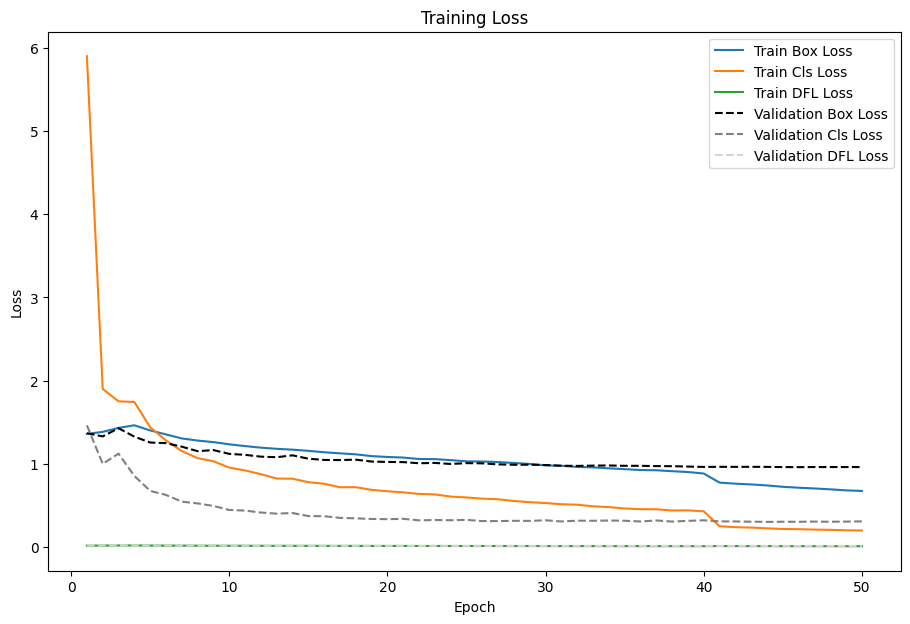

In [9]:
import pandas as pd 
import matplotlib.pyplot as plt

results = pd.read_csv(r"D:\Programmer\Project\Sign Language Detector\runs\detect\runs\detect\asl_yolo26s\results.csv")

plt.figure(figsize=(11, 7))
plt.plot(results['epoch'], results['train/box_loss'], label='Train Box Loss')
plt.plot(results['epoch'], results['train/cls_loss'], label='Train Cls Loss')
plt.plot(results['epoch'], results['train/dfl_loss'], label='Train DFL Loss')
plt.plot(results['epoch'], results['val/box_loss'], label='Validation Box Loss', linestyle='--', color='black')
plt.plot(results['epoch'], results['val/cls_loss'], label='Validation Cls Loss', linestyle='--', color='gray')
plt.plot(results['epoch'], results['val/dfl_loss'], label='Validation DFL Loss', linestyle='--', color='lightgray')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

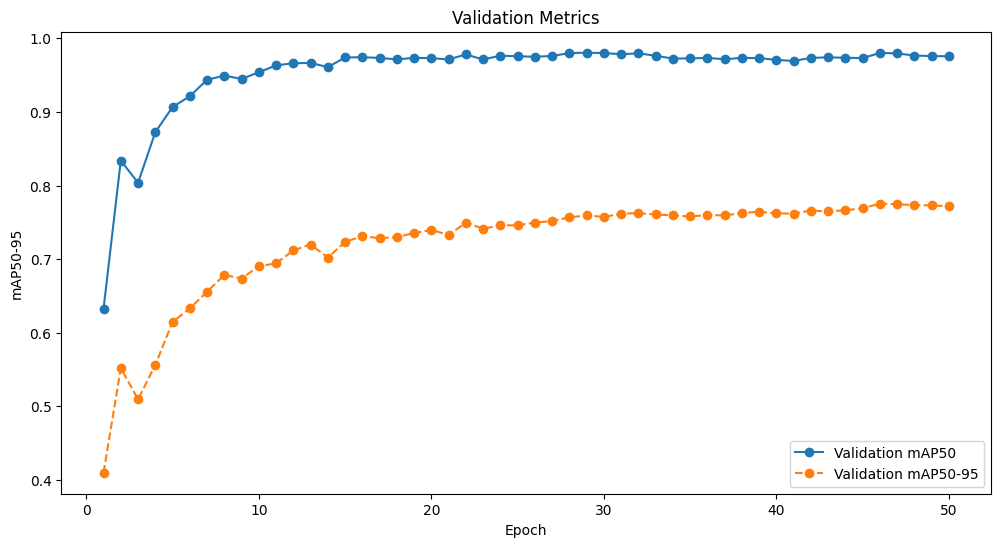

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(results['epoch'], results['metrics/mAP50(B)'], label='Validation mAP50', marker='o')
plt.plot(results['epoch'], results['metrics/mAP50-95(B)'], label='Validation mAP50-95', marker='o', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('mAP50-95')
plt.title('Validation Metrics')
plt.legend()
plt.show()

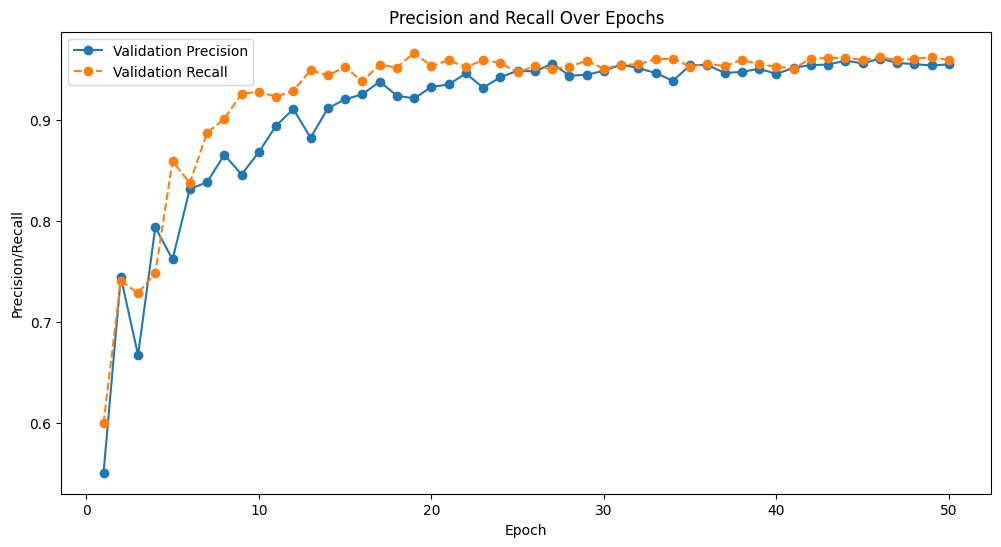

In [ ]:
# Fix: `results` may have been overwritten by YOLO predict() output (a list)
if not hasattr(results, "columns"):
	candidate_csvs = [

		Path(r"runs\detect\exp\results.csv"),
	]

	csv_path = next((p for p in candidate_csvs if p.exists()), None)
	if csv_path is None:
		raise FileNotFoundError("Could not find training results.csv")
	results = pd.read_csv(csv_path)

plt.figure(figsize=(12, 6))
plt.plot(results["epoch"], results["metrics/precision(B)"], label="Validation Precision", marker="o")
plt.plot(results["epoch"], results["metrics/recall(B)"], label="Validation Recall", marker="o", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Precision/Recall")
plt.title("Precision and Recall Over Epochs")
plt.legend()
plt.show()

In [13]:
best_model = YOLO(r"runs\detect\runs\detect\asl_yolo26s\weights\best.pt")
test_dir = r"American-sign-language-2\images\test"
results = best_model.predict(source=test_dir, save=True, conf=0.35)
print("Inference completed. Results saved in 'runs/detect/predict' directory.")


image 1/822 d:\Programmer\Project\Sign Language Detector\American-sign-language-2\images\test\-ePyJBmOJ9s_mp4-8_jpg.rf.a8b56428bbe8d2b80bc050fbbbc514c0.jpg: 640x640 1 eat, 139.5ms
image 2/822 d:\Programmer\Project\Sign Language Detector\American-sign-language-2\images\test\01831_augmented_darkness_mp4-11_jpg.rf.671ae9fc1c98e3cbc5c1c9bfda6b510c.jpg: 640x640 1 bill, 20.2ms
image 3/822 d:\Programmer\Project\Sign Language Detector\American-sign-language-2\images\test\01831_augmented_darkness_mp4-7_jpg.rf.609ce414c5f5952cdb957434f547c51b.jpg: 640x640 1 bill, 20.1ms
image 4/822 d:\Programmer\Project\Sign Language Detector\American-sign-language-2\images\test\01831_mp4-5_jpg.rf.a823f68cb36365cb747e7054e1a6d9af.jpg: 640x640 1 bill, 20.3ms
image 5/822 d:\Programmer\Project\Sign Language Detector\American-sign-language-2\images\test\01831_mp4-8_jpg.rf.7965574e4f96a9dcf40deee426ef6b54.jpg: 640x640 1 bill, 20.3ms
image 6/822 d:\Programmer\Project\Sign Language Detector\American-sign-language-2\im